In [1]:
from DataCleaning import load_data,get_info,get_shape,get_head,get_summary_statistics,check_data_types,check_missing_values,check_duplicates,check_outliers,check_inconsistent_data,clean_data
from FeatureEngineering import feature_engineering,customer_features,rfm
from visualizations import merge_rfm,plot_seasonality,plot_rfm_segment_distribution,plot_dominant_segment_heatmap,plot_discount_vs_profit_margin,plot_revenue_by_region,plot_revenue_trend,plot_top_products_revenue_vs_profit,plot_aov_by_segment

import matplotlib.pyplot as plt


## 1. Load Data

In [2]:
path="Sample - Superstore 2019.csv"
df=load_data(path)

## 2. Inspect Data

In [3]:
get_info(df)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 9996 entries, 0 to 9995
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          9994 non-null   float64       
 1   Order ID        9994 non-null   str           
 2   Order Date      9994 non-null   datetime64[us]
 3   Ship Date       9994 non-null   datetime64[us]
 4   Ship Mode       9994 non-null   str           
 5   Customer ID     9994 non-null   str           
 6   Customer Name   9994 non-null   str           
 7   Segment         9994 non-null   str           
 8   Country/Region  9994 non-null   str           
 9   City            9994 non-null   str           
 10  State           9994 non-null   str           
 11  Postal Code     9983 non-null   float64       
 12  Region          9994 non-null   str           
 13  Product ID      9994 non-null   str           
 14  Category        9994 non-null   str           

In [4]:
get_head(df)

   Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0     1.0  CA-2018-152156 2018-11-08 2018-11-11    Second Class    CG-12520   
1     2.0  CA-2018-152156 2018-11-08 2018-11-11    Second Class    CG-12520   
2     3.0  CA-2018-138688 2018-06-12 2018-06-16    Second Class    DV-13045   
3     4.0  US-2017-108966 2017-10-11 2017-10-18  Standard Class    SO-20335   
4     5.0  US-2017-108966 2017-10-11 2017-10-18  Standard Class    SO-20335   

     Customer Name    Segment Country/Region             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0     42420.0   South  FUR-BO-10

In [5]:
get_shape(df)

Dataset Shape:
(9996, 21)


In [6]:
get_summary_statistics(df)

Summary Statistics:
             Row ID        Order ID                  Order Date  \
count   9994.000000            9994                        9994   
unique          NaN            5009                         NaN   
top             NaN  CA-2019-100111                         NaN   
freq            NaN              14                         NaN   
mean    4997.500000             NaN  2018-04-30 10:03:51.979187   
min        1.000000             NaN         2016-01-03 00:00:00   
25%     2499.250000             NaN         2017-05-23 00:00:00   
50%     4997.500000             NaN         2018-06-26 00:00:00   
75%     7495.750000             NaN         2019-05-14 00:00:00   
max     9994.000000             NaN         2019-12-30 00:00:00   
std     2885.163629             NaN                         NaN   

                         Ship Date       Ship Mode Customer ID  Customer Name  \
count                         9994            9994        9994           9994   
unique       

In [7]:
check_data_types(df)

Data Types:
Row ID                   float64
Order ID                     str
Order Date        datetime64[us]
Ship Date         datetime64[us]
Ship Mode                    str
Customer ID                  str
Customer Name                str
Segment                      str
Country/Region               str
City                         str
State                        str
Postal Code              float64
Region                       str
Product ID                   str
Category                     str
Sub-Category                 str
Product Name                 str
Sales                    float64
Quantity                 float64
Discount                 float64
Profit                   float64
dtype: object


In [8]:
check_missing_values(df)

Missing Values:
Row ID             2
Order ID           2
Order Date         2
Ship Date          2
Ship Mode          2
Customer ID        2
Customer Name      2
Segment            2
Country/Region     2
City               2
State              2
Postal Code       13
Region             2
Product ID         2
Category           2
Sub-Category       2
Product Name       2
Sales              2
Quantity           2
Discount           2
Profit             2
dtype: int64


In [9]:
check_duplicates(df)

Duplicate records found: 1


In [10]:
check_outliers(df, 'Sales')

Outliers in Sales:
          Sales
1      731.9400
3      957.5775
7      907.1520
10    1706.1840
11     911.4240
...         ...
9931   683.3320
9942   998.8200
9947  1925.8800
9948  2405.2000
9968   735.9800

[1167 rows x 1 columns]


In [11]:
check_inconsistent_data(
    df,
    ['Ship Mode', 'Segment', 'Country/Region', 'City', 'State', 'Region', 'Category', 'Sub-Category']
)

Inconsistent values in Ship Mode:
<StringArray>
['Second Class', 'Standard Class', 'First Class', 'Same Day', nan]
Length: 5, dtype: str
Inconsistent values in Segment:
<StringArray>
['Consumer', 'Corporate', 'Home Office', nan]
Length: 4, dtype: str
Inconsistent values in Country/Region:
<StringArray>
['United States', nan]
Length: 2, dtype: str
Inconsistent values in City:
<StringArray>
[        'Henderson',       'Los Angeles',   'Fort Lauderdale',
           'Concord',           'Seattle',        'Fort Worth',
           'Madison',       'West Jordan',     'San Francisco',
           'Fremont',
 ...
       'East Orange', 'Arlington Heights',            'Oswego',
       'Coon Rapids',      'San Clemente',   'San Luis Obispo',
        'Springdale',              'Lodi',             'Mason',
                 nan]
Length: 532, dtype: str
Inconsistent values in State:
<StringArray>
[            'Kentucky',           'California',              'Florida',
       'North Carolina',          

In [12]:
df = clean_data(df)

Duplicate records found: 0


## 4. Feature Engineering

In [13]:

df=feature_engineering(df)

In [14]:
CustomerFeatures=customer_features(df)

In [15]:
CustomerFeatures

,Customer ID,order_count,total_spend,total_profit,avg_order_value,first_order,last_order,Customer Tenure Days
0,AA-10315,5,959.920,170.5439,106.657778,2016-03-31,2019-06-29,1185
1,AA-10375,9,556.410,162.3870,39.743571,2016-04-21,2019-12-11,1329
2,AA-10480,4,1790.512,435.8274,149.209333,2016-05-04,2019-04-15,1076
3,AA-10645,6,1088.700,242.7249,77.764286,2016-06-22,2019-11-05,1231
4,AB-10015,3,886.156,129.3465,147.692667,2016-02-18,2018-11-10,996
...,...,...,...,...,...,...,...,...
785,XP-21865,11,2374.658,621.2300,84.809214,2016-01-20,2019-11-17,1397
786,YC-21895,3,569.364,100.8334,113.872800,2016-11-17,2018-09-06,658
787,YS-21880,7,1926.876,255.4650,214.097333,2017-01-12,2019-08-18,948
788,ZC-21910,13,2047.373,125.4253,78.745115,2016-10-13,2019-11-06,1119


In [16]:
rfm=rfm(df)

In [17]:
rfm

,Customer ID,recency,frequency,monetary_value,r_score,f_score,m_score,RFM_Score,Customer Segment
784,WB-21850,21,11,3131.974,5,5,5,555,Champion
753,TP-21130,9,8,1582.566,5,5,5,555,Champion
621,RB-19465,10,11,2276.064,5,5,5,555,Champion
616,RA-19915,13,9,1896.145,5,5,5,555,Champion
699,SM-20950,26,11,1940.360,5,5,5,555,Champion
...,...,...,...,...,...,...,...,...,...
725,SW-20755,535,2,179.560,1,1,1,111,Lost
145,CJ-11875,366,1,16.520,1,1,1,111,Lost
144,CH-12070,792,2,409.260,1,1,1,111,Lost
143,CG-12520,339,3,416.840,1,1,1,111,Lost


In [18]:
df.columns.tolist()

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country/Region',
 'City',
 'State',
 'Postal Code',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales',
 'Quantity',
 'Discount',
 'Profit',
 'Month',
 'Year',
 'Day',
 'Quarter',
 'Shipping Duration',
 'Is Weekend',
 'Unit Price',
 'Profit Margin']

In [19]:
get_head(df)

   Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0       1  CA-2018-152156 2018-11-08 2018-11-11    Second Class    CG-12520   
2       3  CA-2018-138688 2018-06-12 2018-06-16    Second Class    DV-13045   
4       5  US-2017-108966 2017-10-11 2017-10-18  Standard Class    SO-20335   
5       6  CA-2016-115812 2016-06-09 2016-06-14  Standard Class    BH-11710   
6       7  CA-2016-115812 2016-06-09 2016-06-14  Standard Class    BH-11710   

     Customer Name    Segment Country/Region             City  ... Discount  \
0      Claire Gute   Consumer  United States        Henderson  ...      0.0   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...      0.0   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...      0.2   
5  Brosina Hoffman   Consumer  United States      Los Angeles  ...      0.0   
6  Brosina Hoffman   Consumer  United States      Los Angeles  ...      0.0   

    Profit Month  Year        Day Quarter Shipping

In [20]:
df=merge_rfm(df, rfm)

In [21]:
df.columns.tolist()

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country/Region',
 'City',
 'State',
 'Postal Code',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales',
 'Quantity',
 'Discount',
 'Profit',
 'Month',
 'Year',
 'Day',
 'Quarter',
 'Shipping Duration',
 'Is Weekend',
 'Unit Price',
 'Profit Margin',
 'Customer Segment']

In [22]:
check_data_types(df)

Data Types:
Row ID                        int64
Order ID                        str
Order Date           datetime64[us]
Ship Date            datetime64[us]
Ship Mode                  category
Customer ID                     str
Customer Name                   str
Segment                    category
Country/Region             category
City                       category
State                      category
Postal Code                     str
Region                     category
Product ID                      str
Category                   category
Sub-Category               category
Product Name                    str
Sales                       float64
Quantity                    float64
Discount                    float64
Profit                      float64
Month                         int32
Year                          int32
Day                             str
Quarter                       int32
Shipping Duration             int64
Is Weekend                     bool
Unit Price      

## 5. Questions and Viz


##### A. What's the distribution of customers across RFM Segments?

How many customers fall into each RFM segment (Champion, Loyal, Promising, At Risk, Lost), and what does the overall shape of the customer base tell us about retention health and where the biggest opportunities or risks are concentrated?


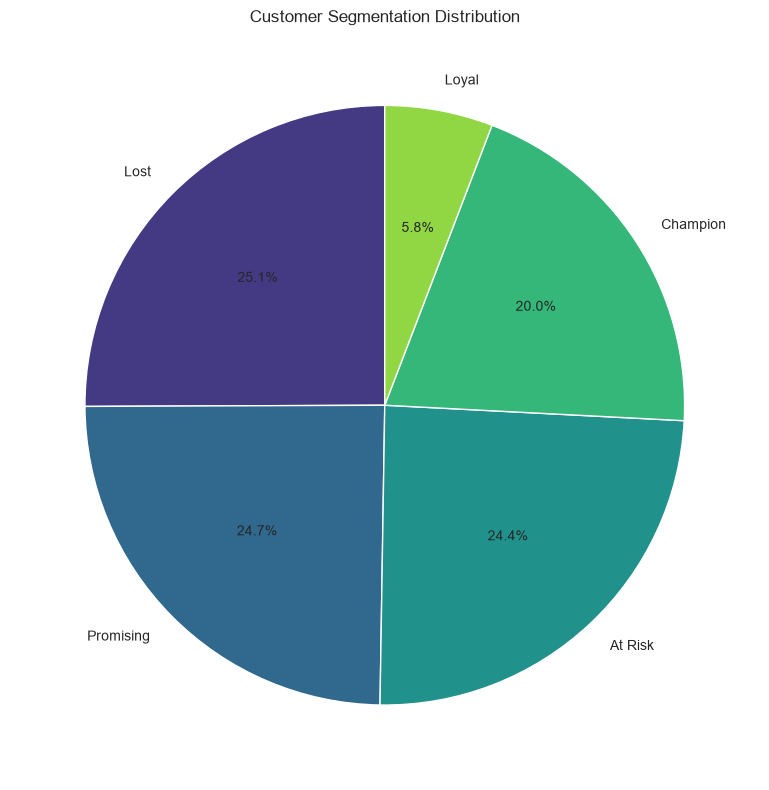

In [23]:
plot_rfm_segment_distribution(rfm)

**Insights:**
- The customer base splits into three roughly equal large groups — **Lost (25.1%)**, **Promising (24.7%)**, and **At Risk (24.4%)** — together accounting for ~74% of all customers.
- Only **20.0%** of customers are current **Champions**, and a mere **5.8%** are **Loyal**, meaning fewer than 1 in 4 customers sit in a healthy, high-value relationship with the business today.
- The near-tie between Lost and Promising is a warning sign: for every customer being successfully nurtured into loyalty, roughly one is churning out — retention efforts are not outpacing customer drop-off.
- **Action point:** the At Risk segment (24.4%) is the highest-leverage target for win-back campaigns, since these customers haven't fully lapsed yet and are still recoverable before joining the Lost pool.


##### B. What is the dominant (most frequent) RFM segment in each city/state?

For the states generating the most customer activity, which single RFM segment shows up most often, and does the dominant segment shift meaningfully from state to state or stay fairly consistent nationwide?


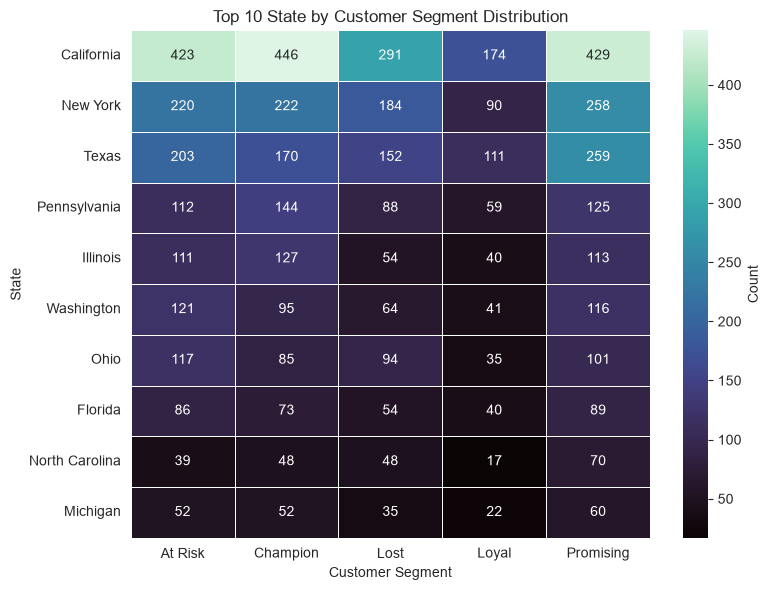

In [24]:
dominant_df = plot_dominant_segment_heatmap(df, region_col='State')

**Insights:**
- **California** dominates every single segment column and is the only state with any segment count above 400, confirming it's not just the top revenue state (see chart C) but also the largest customer base by a wide margin.
- Within California, **Champion (446)** and **Promising (429)** are nearly tied as the two largest segments, while **Loyal (174)** is comparatively small — mirroring the national pattern from chart A where Loyal is the smallest slice everywhere.
- **Texas** stands out for a different reason: its **Promising** count (259) exceeds its **Champion** count (170), suggesting the Texas customer base skews newer/less proven relative to California and New York, where Champion consistently outnumbers Promising.
- Smaller states like **North Carolina** and **Michigan** show much flatter distributions across segments, meaning no single segment dominates — likely just a function of lower overall order volume rather than a structurally different customer mix.


##### C. Which city/state generates the highest revenue/profit overall?

Which states are the biggest revenue contributors, how concentrated is revenue in a small number of states, and how big is the gap between the top state and the rest of the pack?


d:\Data Analysis\Mini Project 1\visualizations.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=revenue.values, y=revenue.index, palette='rocket')


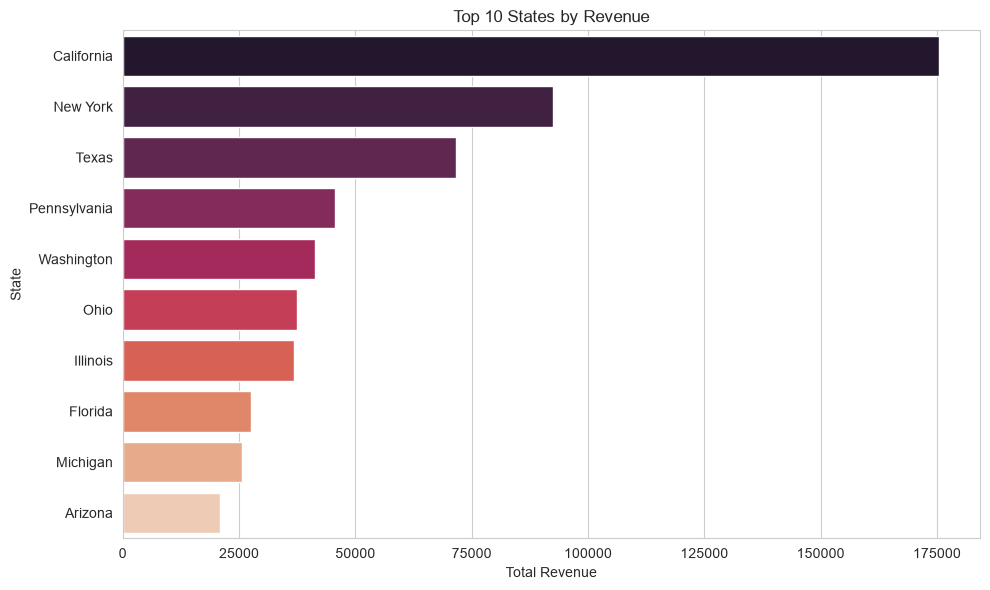

In [25]:
plot_revenue_by_region(df, region_col='State', top_n=10)

**Insights:**
- **California** is the runaway leader at ~\$175K in revenue — nearly **double** New York (~\$92K), the second-place state, and more than double every other state in the top 10.
- Revenue drops off sharply after the top 3: **California, New York, and Texas** (~\$72K) together likely account for a disproportionate share of total company revenue, while states ranked 4th–10th (Pennsylvania, Washington, Ohio, Illinois, Florida, Michigan, Arizona) cluster much closer together in the \$21K–\$46K range.
- This heavy geographic concentration means the business is exposed to concentration risk — a downturn in California specifically would have an outsized impact on total revenue compared to any other single state.
- Combined with chart B, California's revenue lead is backed by genuinely more customers, not just higher spend per customer — so growth strategies elsewhere might focus on customer acquisition rather than just increasing order values.


##### D. How does revenue/sales trend over time (monthly/yearly)?

How has monthly revenue evolved from 2016 through 2019 — is there a consistent upward trajectory, and are there recurring seasonal peaks/dips that repeat every year regardless of overall growth?


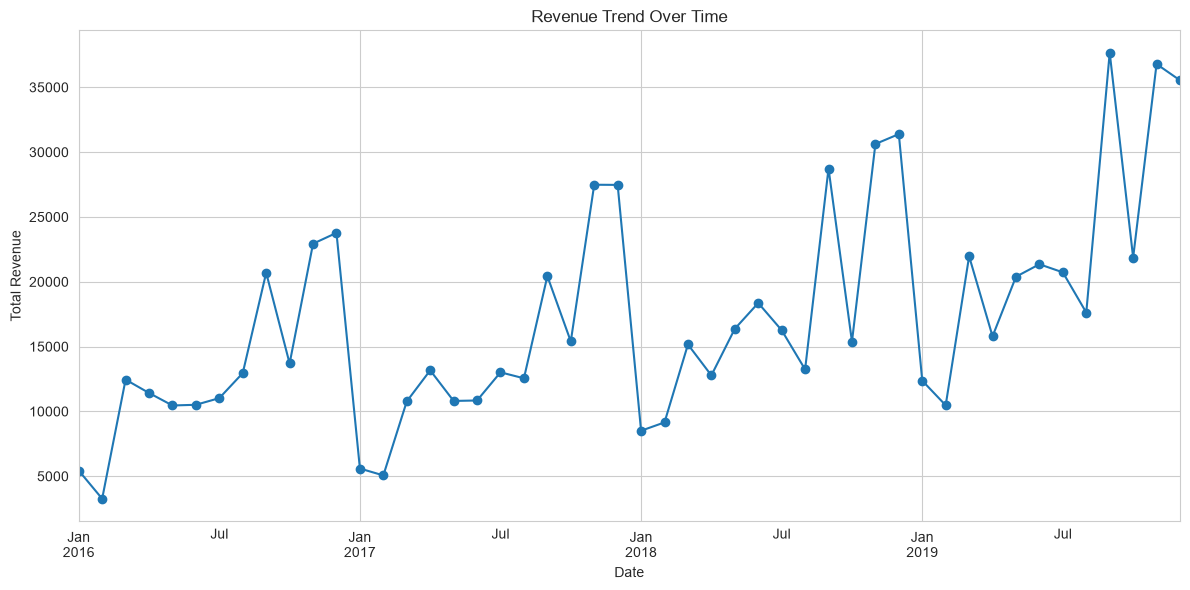

In [26]:
plot_revenue_trend(df)

**Insights:**
- Revenue shows a clear **long-term upward trend** from 2016 (~\$5K–13K/month) to 2019 (peaks above \$35K/month), roughly tripling over the four-year window.
- Every year shows the same **seasonal fingerprint**: a sharp trough in **January–February**, followed by a steady climb into a **November/December peak** — consistent with holiday-driven retail buying (also confirmed in chart H).
- 2019 is notably more volatile than earlier years, with sharper swings between consecutive months (e.g. a spike near \$37K followed by a drop to ~\$22K) — this could reflect either genuine demand spikes (bulk/corporate orders) or growing month-to-month unpredictability as the business scales.
- The recurring Jan/Feb dip every single year suggests this is a structural seasonal pattern the business can plan inventory, staffing, and promotions around, rather than a one-off anomaly.


##### E. What are the top products or categories by profit/revenue?

Which sub-categories bring in the most revenue, which bring in the most profit, and — most importantly — where do the two rankings disagree (i.e. sub-categories that sell a lot but barely profit, or profit a lot without leading in sales)?


d:\Data Analysis\Mini Project 1\visualizations.py:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_revenue.values, y=top_revenue.index, palette='crest', ax=axes[0])
d:\Data Analysis\Mini Project 1\visualizations.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_profit.values, y=top_profit.index, palette='flare', ax=axes[1])


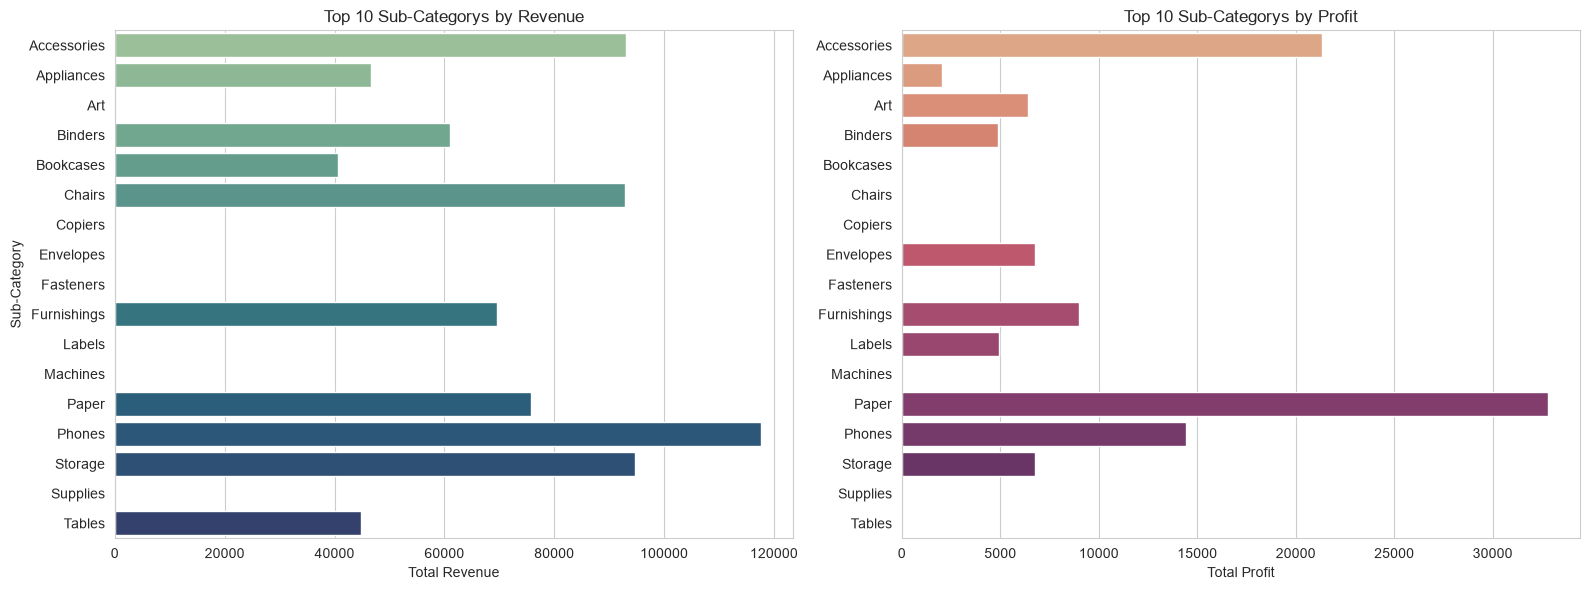

,Sales,Profit
Sub-Category,,
Phones,117585.5380,14416.5916
Storage,94705.9560,6735.5406
Accessories,93024.6840,21316.8009
Chairs,92925.4670,1626.0581
Paper,75857.9560,32795.3693
Furnishings,69562.1520,8988.7917
Binders,61012.2150,4901.3211
Appliances,46729.7030,2028.9706
Tables,44837.0475,-8636.2699


In [27]:
plot_top_products_revenue_vs_profit(df, product_col='Sub-Category', top_n=10)

**Insights:**
- **Phones** lead in raw revenue (~\$118K) but only produce moderate profit (~\$14.5K) — a relatively thin margin for the top revenue driver.
- **Paper**, despite lower revenue (~\$76K) than Phones or Storage, generates the **highest profit of any sub-category (~\$33K)** — more than double Phones' profit on less revenue, making it the most profit-efficient product line in the top 10.
- **Accessories** is the second-most profitable sub-category (~\$21K) on relatively modest revenue (~\$93K), reinforcing that high revenue doesn't guarantee high profit.
- Several high-revenue sub-categories — **Chairs, Bookcases, Storage, and Tables** — don't appear (or barely appear) in the profit ranking at all, implying their profit is low or possibly negative despite strong sales; these are strong candidates for a discount/pricing review (see chart G, since heavy discounting is linked to negative margins).
- **Takeaway:** revenue leadership and profit leadership belong to different sub-categories, so any strategy purely optimizing for sales volume (e.g. Phones, Storage) would miss where the actual profit is coming from (Paper, Accessories).


##### F. What's the Average Order Value (AOV) for each RFM Segment?

Do higher-value RFM segments (Champion, Loyal) actually spend more per order than lower-value segments (At Risk, Lost, Promising), or is order size fairly similar across segments regardless of loyalty status?


d:\Data Analysis\Mini Project 1\visualizations.py:120: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=aov.values, y=aov.index, palette='flare')


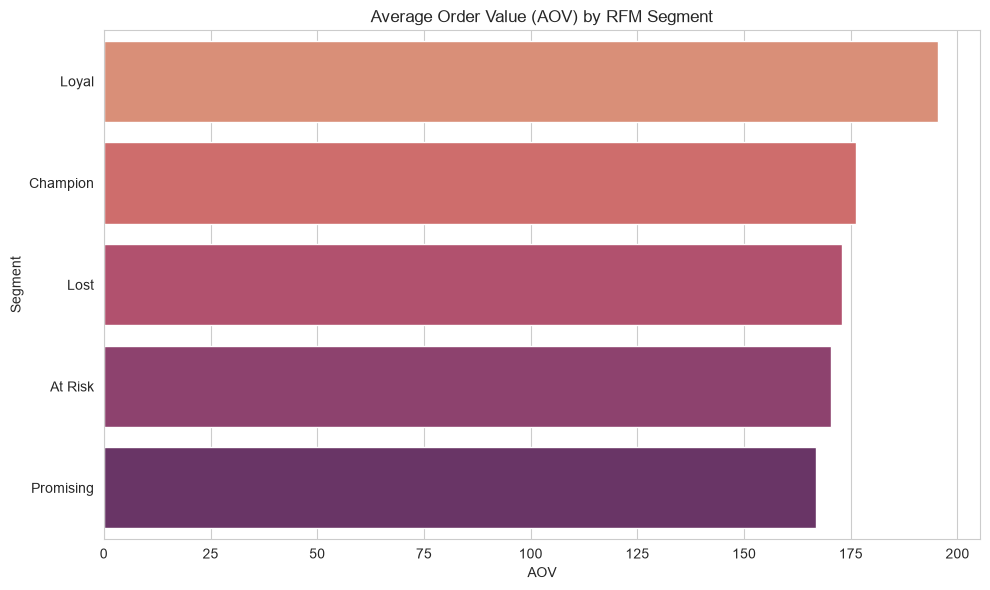

In [28]:
plot_aov_by_segment(df)

**Insights:**
- **Loyal** customers have the highest Average Order Value (~\$195), consistent with them being long-tenured, trust-building customers — though this is the smallest segment by size (only 5.8% of customers, per chart A).
- Surprisingly, **AOV differences across segments are fairly narrow** — the gap between the highest (Loyal, ~\$195) and lowest (Promising, ~\$165) is only around \$30, roughly a 15% spread.
- **Lost** customers still have a relatively high AOV (~\$173) — higher than both At Risk and Promising — suggesting that churned customers weren't lost due to low order value; they may have left for reasons unrelated to how much they spent per transaction (e.g. service, competition, one-time need).
- Because AOV alone doesn't vary dramatically by segment, the real differentiator between segments is more likely **purchase frequency and recency** (the "F" and "R" in RFM) rather than basket size — meaning retention campaigns should focus on driving repeat visits rather than upselling bigger orders.


##### G. Does discount level affect profit margin?

As discount percentage increases, what happens to profit margin — is the relationship linear, and is there an identifiable discount threshold beyond which orders become unprofitable?


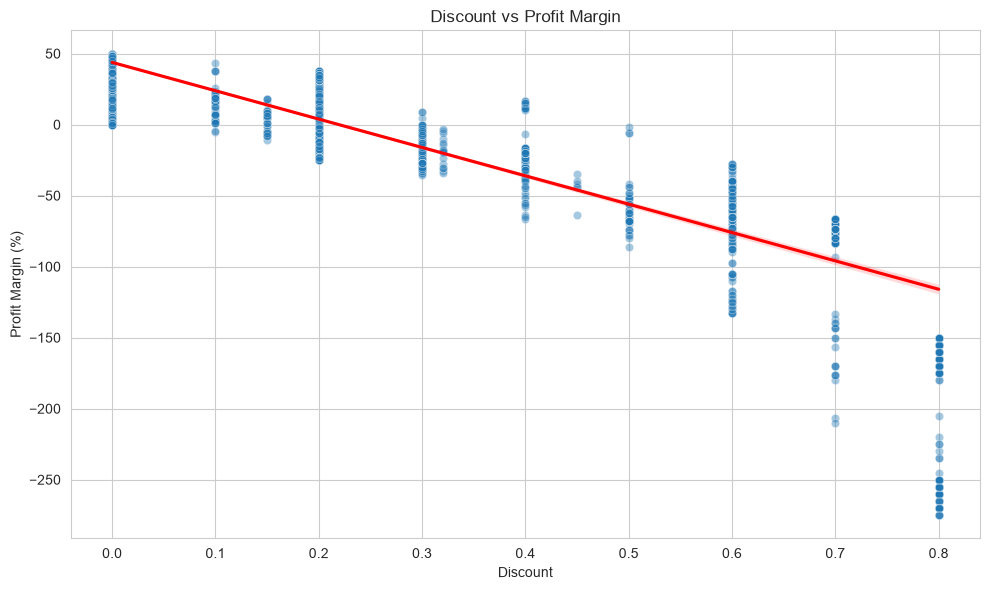

Correlation: -0.870


In [29]:
plot_discount_vs_profit_margin(df)

**Insights:**
- There's a clear **negative linear relationship** between discount and profit margin: the fitted trend line drops from roughly **+45% margin at 0% discount** to about **-115% margin at 80% discount**.
- The **break-even point sits around a 20% discount** — orders discounted below this threshold are typically still profitable (positive margin), while discounts beyond ~20–25% push the average order into a loss.
- Losses accelerate sharply at high discount levels: orders discounted at **60–80%** frequently show margins between **-150% and -280%**, meaning the company is losing far more than the item's value on these transactions.
- The wide vertical spread of points at each discount level (e.g. at 0.3 discount, margins range from about +10% to -35%) shows discount level alone doesn't fully determine profitability — other factors (product cost, category, shipping) are also at play, but discount is clearly the dominant driver.
- **Action point:** discounting policy above ~25–30% should be reviewed or restricted, since it's strongly associated with loss-making orders rather than incremental profitable volume.


##### H. Is there seasonality in sales across months/quarters?

Which months consistently drive the most sales, which are the slowest, and does the pattern suggest a predictable annual seasonal cycle (e.g. holiday-driven Q4 spike) rather than random month-to-month noise?


d:\Data Analysis\Mini Project 1\visualizations.py:149: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=seasonal.index, y=seasonal.values, palette='mako')


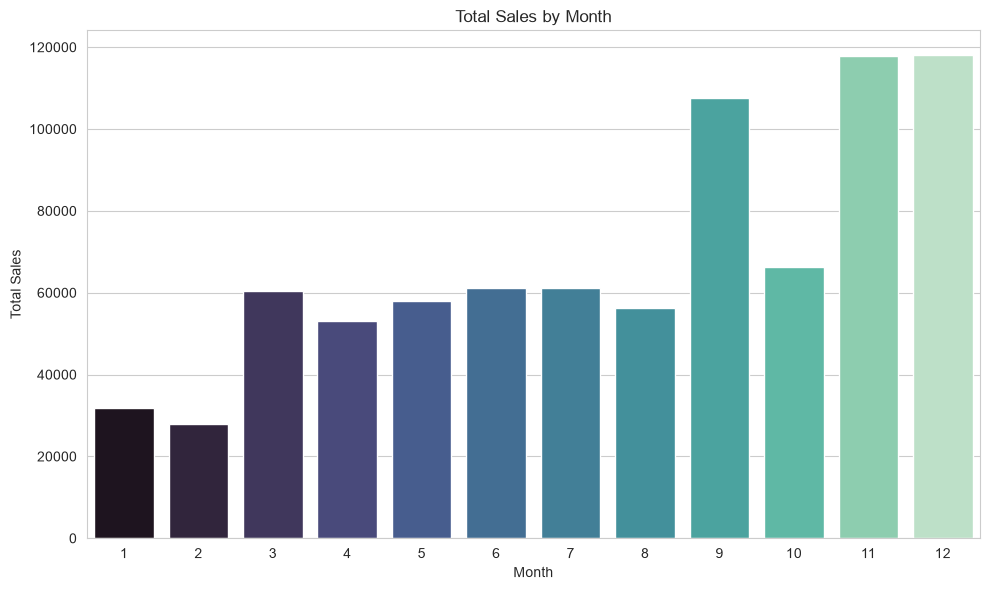

In [30]:
plot_seasonality(df)

**Insights:**
- Sales show a strong **seasonal ramp-up through the year**: **January and February are the weakest months** (~\$28K–32K), roughly a third of the strongest months.
- There's a **mid-year plateau** from March through August, with sales holding fairly steady in the \$53K–61K range — no strong month dominates this stretch.
- **September** shows a sudden jump to ~\$107K, nearly double the preceding months — likely a back-to-school or fiscal-year-end corporate buying effect — before dipping slightly in October.
- **November and December are the clear peak months**, both close to **\$118K**, over **4x** the January low — confirming the strong Q4/holiday seasonality also visible in the multi-year trend (chart D).
- This pattern is consistent enough to treat as a **reliable planning signal**: inventory build-up, staffing, and marketing spend should be weighted heavily toward September and November–December, with leaner planning for the January–February slowdown.
